# Delivery Time Prediction - Phase 9: Model Evaluation

## Executive Overview
Welcome to **Phase 9: Model Evaluation** of the Delivery Time Prediction machine learning project.

In **Phase 7**, we established our foundational **heuristic baseline** ($57.05$ min training mean). In **Phase 8**, we trained three candidate supervised regression models:
1. **Linear Regression** (Ordinary Least Squares)
2. **Decision Tree Regressor** (Recursive binary partitioning, unpruned)
3. **Random Forest Regressor** (100 bagged ensemble trees)

This phase conducts a **rigorous, multi-dimensional evaluation** of all candidate models on both training and holdout test partitions.

### Phase Objectives
1. **Comprehensive Metric Calculation**: Compute **MAE**, **MSE**, **RMSE**, and **$R^2$** on the holdout test set for all models and the Phase 7 baseline.
2. **Plain-English Metric Explanations**: Define each evaluation metric in simple, beginner-friendly machine learning terms.
3. **Overfitting & Generalization Diagnosis**: Quantify the train-vs-test generalization gap for every model to detect signs of memorization, high variance, or underfitting.
4. **Multi-Panel Visual Diagnostics**: Generate Actual vs. Predicted scatter plots, residual distribution curves, and error comparison charts.
5. **Slice-Based Error Analysis**: Dissect prediction errors across key operational dimensions (distance tiers, weather hazards, traffic intensity, vehicle types, and delivery duration scale) to reveal where models are highly accurate vs. where large errors concentrate.
6. **Strict Phase Boundaries**:
   * The holdout test set is used **exclusively for evaluation**.
   * **No hyperparameter tuning** is conducted (deferred to Phase 11).
   * **No model changes** are made based on test feedback.
   * **No final model selection** is declared yet (deferred to Phase 12).

## 1. Evaluation Metrics Explained in Simple ML Terms

Evaluating regression models requires examining errors from multiple perspectives. Below are plain-English explanations of the four standard metrics used in this project:

### 1. MAE (Mean Absolute Error)
* **Mathematical Definition**: $\text{MAE} = \frac{1}{N} \sum_{i=1}^N |y_i - \hat{y}_i|$
* **Plain-English Meaning**: *"On average, by how many minutes is our prediction off?"*
* **Key Characteristics**: Highly intuitive for delivery dispatchers and business stakeholders. An error of $+10$ minutes (underestimating) is penalized exactly the same as $-10$ minutes (overestimating). It is robust to extreme outliers because errors are not squared.

---

### 2. MSE (Mean Squared Error)
* **Mathematical Definition**: $\text{MSE} = \frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}_i)^2$
* **Plain-English Meaning**: *"What is the average squared penalty across all delivery mistakes?"*
* **Key Characteristics**: Because mistakes are squared, an error of $10$ minutes is penalized $100\times$, whereas an error of $2$ minutes is penalized only $4\times$. Units are in "squared minutes" ($\text{min}^2$), making it difficult to interpret intuitively, but its continuous derivative makes it mathematically ideal for loss optimization.

---

### 3. RMSE (Root Mean Squared Error)
* **Mathematical Definition**: $\text{RMSE} = \sqrt{\text{MSE}} = \sqrt{\frac{1}{N} \sum_{i=1}^N (y_i - \hat{y}_i)^2}$
* **Plain-English Meaning**: *"What is our average error magnitude when large mistakes are penalized extra heavily?"*
* **Key Characteristics**: Returns the error metric back to natural units (minutes). Whenever RMSE is significantly higher than MAE, it reveals that the model makes occasional catastrophic prediction errors (outliers in the error distribution).

---

### 4. $R^2$ (Coefficient of Determination)
* **Mathematical Definition**: $R^2 = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}} = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$
* **Plain-English Meaning**: *"What percentage of the fluctuations in delivery times is successfully explained by our model's predictors?"*
* **Key Characteristics**: A score of $1.0$ ($100\%$) represents perfect predictions. A score of $0.0$ means the model does no better than simply guessing the average delivery duration every time. Negative values indicate the model performs even worse than guessing the historical mean.

In [1]:
import os
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

# Add project root to sys.path for modular imports
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.preprocess import build_full_preprocessor
from src.train import (
    calculate_regression_metrics,
    get_candidate_regressors,
    train_and_evaluate_model,
    update_model_comparison,
)

# Visual display configuration
pd.set_option('display.max_columns', 25)
pd.set_option('display.width', 1000)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

print("Environment and modules initialized successfully.")
print(f"Python: {sys.version.split()[0]} | Pandas: {pd.__version__} | Scikit-Learn: 1.9.1 | NumPy: {np.__version__}")
print("Source modules loaded from 'src.preprocess' & 'src.train': build_full_preprocessor, calculate_regression_metrics, get_candidate_regressors, train_and_evaluate_model")

Environment and modules initialized successfully.
Python: 3.11.9 | Pandas: 3.0.6 | Scikit-Learn: 1.9.1 | NumPy: 2.4.6
Source modules loaded from 'src.preprocess' & 'src.train': build_full_preprocessor, calculate_regression_metrics, get_candidate_regressors, train_and_evaluate_model


### Analysis & Observations: Setup
* All analytical, visualization, and Scikit-Learn evaluation modules loaded cleanly.
* Reusable functions from `src/train.py` (now computing MAE, MSE, RMSE, and $R^2$) guarantee consistency with the backend registry.

## 2. Ingesting Partitioned Datasets & Rebuilding Models

We load the clean 80/20 train/test partitions from `data/processed/` and retrain candidate models within clean pipelines on `(X_train, y_train)` to extract both training and testing prediction vectors.

In [2]:
DATA_DIR = os.path.join('..', 'data', 'processed')
X_train = pd.read_csv(os.path.join(DATA_DIR, 'X_train.csv'))
X_test = pd.read_csv(os.path.join(DATA_DIR, 'X_test.csv'))
y_train = pd.read_csv(os.path.join(DATA_DIR, 'y_train.csv'))['Delivery_Time_min']
y_test = pd.read_csv(os.path.join(DATA_DIR, 'y_test.csv'))['Delivery_Time_min']

# Baseline predictions
baseline_val = float(y_train.mean())
base_train_preds = np.full(len(y_train), baseline_val, dtype=float)
base_test_preds = np.full(len(y_test), baseline_val, dtype=float)

# Candidate model pipelines
pipelines = {
    'Linear Regression': Pipeline([('preprocessor', build_full_preprocessor()), ('regressor', LinearRegression())]),
    'Decision Tree': Pipeline([('preprocessor', build_full_preprocessor()), ('regressor', DecisionTreeRegressor(random_state=42))]),
    'Random Forest': Pipeline([('preprocessor', build_full_preprocessor()), ('regressor', RandomForestRegressor(random_state=42))])
}

predictions = {
    'Baseline': {'train': base_train_preds, 'test': base_test_preds}
}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    predictions[name] = {
        'train': pipe.predict(X_train),
        'test': pipe.predict(X_test)
    }

print("Datasets and model pipelines loaded successfully.")
print(f"Training Partition: ({X_train.shape[0]} rows x {X_train.shape[1]} features, {len(y_train)} labels)")
print(f"Testing Partition:  ({X_test.shape[0]} rows x {X_test.shape[1]} features, {len(y_test)} labels)")
print("Fitted Pipelines:")
for name in pipelines.keys():
    print(f"  + {name:17s} : Fitted strictly on training set.")
print(f"  + Baseline Mean     : {baseline_val:.4f} min (derived exclusively from y_train).")

Datasets and model pipelines loaded successfully.
Training Partition: (800 rows x 12 features, 800 labels)
Testing Partition:  (200 rows x 12 features, 200 labels)
Fitted Pipelines:
  + Linear Regression : Fitted strictly on training set.
  + Decision Tree     : Fitted strictly on training set.
  + Random Forest     : Fitted strictly on training set.
  + Baseline Mean     : 57.0538 min (derived exclusively from y_train).


### Analysis & Observations: Model Preparation
* All 3 model pipelines are instantiated with identical 12-feature preprocessing and fitted strictly on `(X_train, y_train)`.
* In-sample (`train`) and out-of-sample (`test`) predictions are generated, ready for rigorous comparative evaluation.

## 3. Overfitting Diagnosis: Comparing Training vs. Test Performance

A model **overfits** when it memorizes noise and idiosyncratic patterns in the training data rather than discovering genuine underlying relationships. Overfitting is revealed by a **large discrepancy between training and test error**:
* **High Generalization Gap**: Very low training error coupled with significantly higher test error.
* **High Bias (Underfitting)**: Poor performance on both training and test data.
* **Balanced Model**: Consistent, low error across both training and test partitions.

In [3]:
overfit_records = []
assessments = {
    'Baseline': 'High Bias / Zero Fit',
    'Linear Regression': 'Zero Overfitting (Ideal)',
    'Decision Tree': 'Severe Overfitting (100% Memorization)',
    'Random Forest': 'Moderate Overfitting (Bagging Mitigated)'
}

for model_name, preds in predictions.items():
    display_name = 'Baseline (Training Mean)' if model_name == 'Baseline' else model_name
    # Train metrics
    m_train = calculate_regression_metrics(y_train, preds['train'])
    overfit_records.append({
        'Model': display_name,
        'Split': 'Train',
        'MAE (min)': m_train['mae'],
        'MSE (min²)': m_train['mse'],
        'RMSE (min)': m_train['rmse'],
        'R²': m_train['r2'],
        'Overfitting Assessment': assessments[model_name]
    })
    # Test metrics
    m_test = calculate_regression_metrics(y_test, preds['test'])
    overfit_records.append({
        'Model': display_name,
        'Split': 'Test',
        'MAE (min)': m_test['mae'],
        'MSE (min²)': m_test['mse'],
        'RMSE (min)': m_test['rmse'],
        'R²': m_test['r2'],
        'Overfitting Assessment': assessments[model_name]
    })

overfit_df = pd.DataFrame(overfit_records)
print("=" * 100)
print("TRAIN VS. TEST GENERALIZATION AUDIT (OVERFITTING DIAGNOSTIC)")
print("=" * 100)
print(overfit_df.to_string())
print("=" * 100)

TRAIN VS. TEST GENERALIZATION AUDIT (OVERFITTING DIAGNOSTIC)
                      Model  Split  MAE (min)  MSE (min²)  RMSE (min)      R²                    Overfitting Assessment
0  Baseline (Training Mean)  Train    17.8871    495.7234     22.2648  0.0000                      High Bias / Zero Fit
1  Baseline (Training Mean)   Test    17.5014    450.8151     21.2324 -0.0058                      High Bias / Zero Fit
2         Linear Regression  Train     6.6276    117.4652     10.8381  0.7630                  Zero Overfitting (Ideal)
3         Linear Regression   Test     6.1724     82.2857      9.0711  0.8164                  Zero Overfitting (Ideal)
4             Decision Tree  Train     0.0000      0.0000      0.0000  1.0000    Severe Overfitting (100% Memorization)
5             Decision Tree   Test     9.0300    168.0200     12.9623  0.6251    Severe Overfitting (100% Memorization)
6             Random Forest  Train     2.9665     21.7314      4.6617  0.9562  Moderate Overfitting

### In-Depth Overfitting Findings
1. **Decision Tree Regressor (Severe Overfitting)**:
   * **Train Performance**: $\text{MAE} = 0.0000$ min, $\text{MSE} = 0.0000$, $R^2 = 1.0000$.
   * **Test Performance**: $\text{MAE} = 9.0300$ min, $\text{MSE} = 168.0200$, $R^2 = 0.6251$.
   * **Verdict**: The single unpruned decision tree achieved **100% memorization** of the training data because `max_depth=None` allowed the tree to branch repeatedly until every training order occupied a pure, isolated leaf. On unseen test orders, it suffers severe variance, with test error jumping by **$+9.03$ minutes**.

2. **Linear Regression (Zero Overfitting / Superior Generalization)**:
   * **Train Performance**: $\text{MAE} = 6.6276$ min, $R^2 = 0.7630$.
   * **Test Performance**: $\text{MAE} = 6.1724$ min, $R^2 = 0.8164$.
   * **Verdict**: The training and test errors are virtually identical. Because a linear model has strong structural inductive bias, it cannot memorize individual noisy records. It generalizes cleanly and reliably to out-of-sample deliveries.

3. **Random Forest Regressor (Moderate Overfitting, Bagging Controlled)**:
   * **Train Performance**: $\text{MAE} = 2.9665$ min, $R^2 = 0.9562$.
   * **Test Performance**: $\text{MAE} = 6.9794$ min, $R^2 = 0.7876$.
   * **Verdict**: Because its 100 constituent trees are also unpruned, it fits the training partition closely ($R^2 = 0.956$). However, by averaging 100 decorrelated trees trained on bootstrap samples, the ensemble cancels out the massive variance of individual trees, achieving strong out-of-sample test performance ($R^2 = 0.7876$ vs $0.6251$ for Decision Tree).

## 4. Comprehensive Model Comparison on Holdout Test Set

We now synthesize the complete test-set evaluation metrics (**MAE, MSE, RMSE, R²**) and measure exact percentage improvements relative to the Phase 7 Baseline.

In [4]:
eval_rows = []
base_m = calculate_regression_metrics(y_test, predictions['Baseline']['test'])

for name in ['Baseline', 'Linear Regression', 'Decision Tree', 'Random Forest']:
    display_name = 'Baseline (Training Mean)' if name == 'Baseline' else name
    model_type = 'Heuristic Baseline' if name == 'Baseline' else ('Parametric Linear' if name == 'Linear Regression' else ('Non-parametric Tree' if name == 'Decision Tree' else 'Ensemble Bagging'))
    m = calculate_regression_metrics(y_test, predictions[name]['test'])
    
    mae_lift = f"{((m['mae'] - base_m['mae']) / base_m['mae']) * 100:.2f}%"
    rmse_lift = f"{((m['rmse'] - base_m['rmse']) / base_m['rmse']) * 100:.2f}%"
    
    eval_rows.append({
        'Model': display_name,
        'Type': model_type,
        'MAE (min)': m['mae'],
        'MSE (min²)': m['mse'],
        'RMSE (min)': m['rmse'],
        'R²': m['r2'],
        'MAE vs Base': mae_lift,
        'RMSE vs Base': rmse_lift
    })

eval_summary_df = pd.DataFrame(eval_rows)
print("=" * 120)
print("COMPREHENSIVE TEST SET EVALUATION MATRIX (N=200)")
print("=" * 120)
print(eval_summary_df.to_string())
print("=" * 120)

COMPREHENSIVE TEST SET EVALUATION MATRIX (N=200)
                      Model                 Type  MAE (min)  MSE (min²)  RMSE (min)      R² MAE vs Base RMSE vs Base
0  Baseline (Training Mean)   Heuristic Baseline    17.5014    450.8151     21.2324 -0.0058       0.00%        0.00%
1         Linear Regression    Parametric Linear     6.1724     82.2857      9.0711  0.8164     -64.73%      -57.28%
2             Decision Tree  Non-parametric Tree     9.0300    168.0200     12.9623  0.6251     -48.40%      -38.95%
3             Random Forest     Ensemble Bagging     6.9794     95.1849      9.7563  0.7876     -60.12%      -54.05%


### Analysis & Observations: Comparative Metrics
* **Linear Regression leads across all 4 metrics**: Lowest MAE ($6.17$ min), lowest MSE ($82.29$), lowest RMSE ($9.07$ min), and highest $R^2$ ($0.8164$).
* **Random Forest is a competitive second**: MAE of $6.98$ min, MSE of $95.18$, RMSE of $9.76$ min, and $R^2$ of $0.7876$.
* **Decision Tree trails**: High MSE of $168.02$ and RMSE of $12.96$ min confirm that its unpruned leaves suffer from large outlier mispredictions on the test set.

## 5. Visual Diagnostics: Actual vs. Predicted & Residual Distributions

We generate four diagnostic visualizations:
1. **Actual vs. Predicted Deliveries**: Multi-panel scatter plots comparing model predictions against the 45-degree $y=x$ ideal line.
2. **Residual Scatter Plots ($y - \hat{y}$ vs $\hat{y}$)**: Evaluating error homoscedasticity and variance uniformity.
3. **Residual Density Distributions (KDE)**: Comparing error centering, kurtosis, and spread.
4. **Comparative Metric Bar Charts**: Visualizing MAE, RMSE, and $R^2$ across all models.

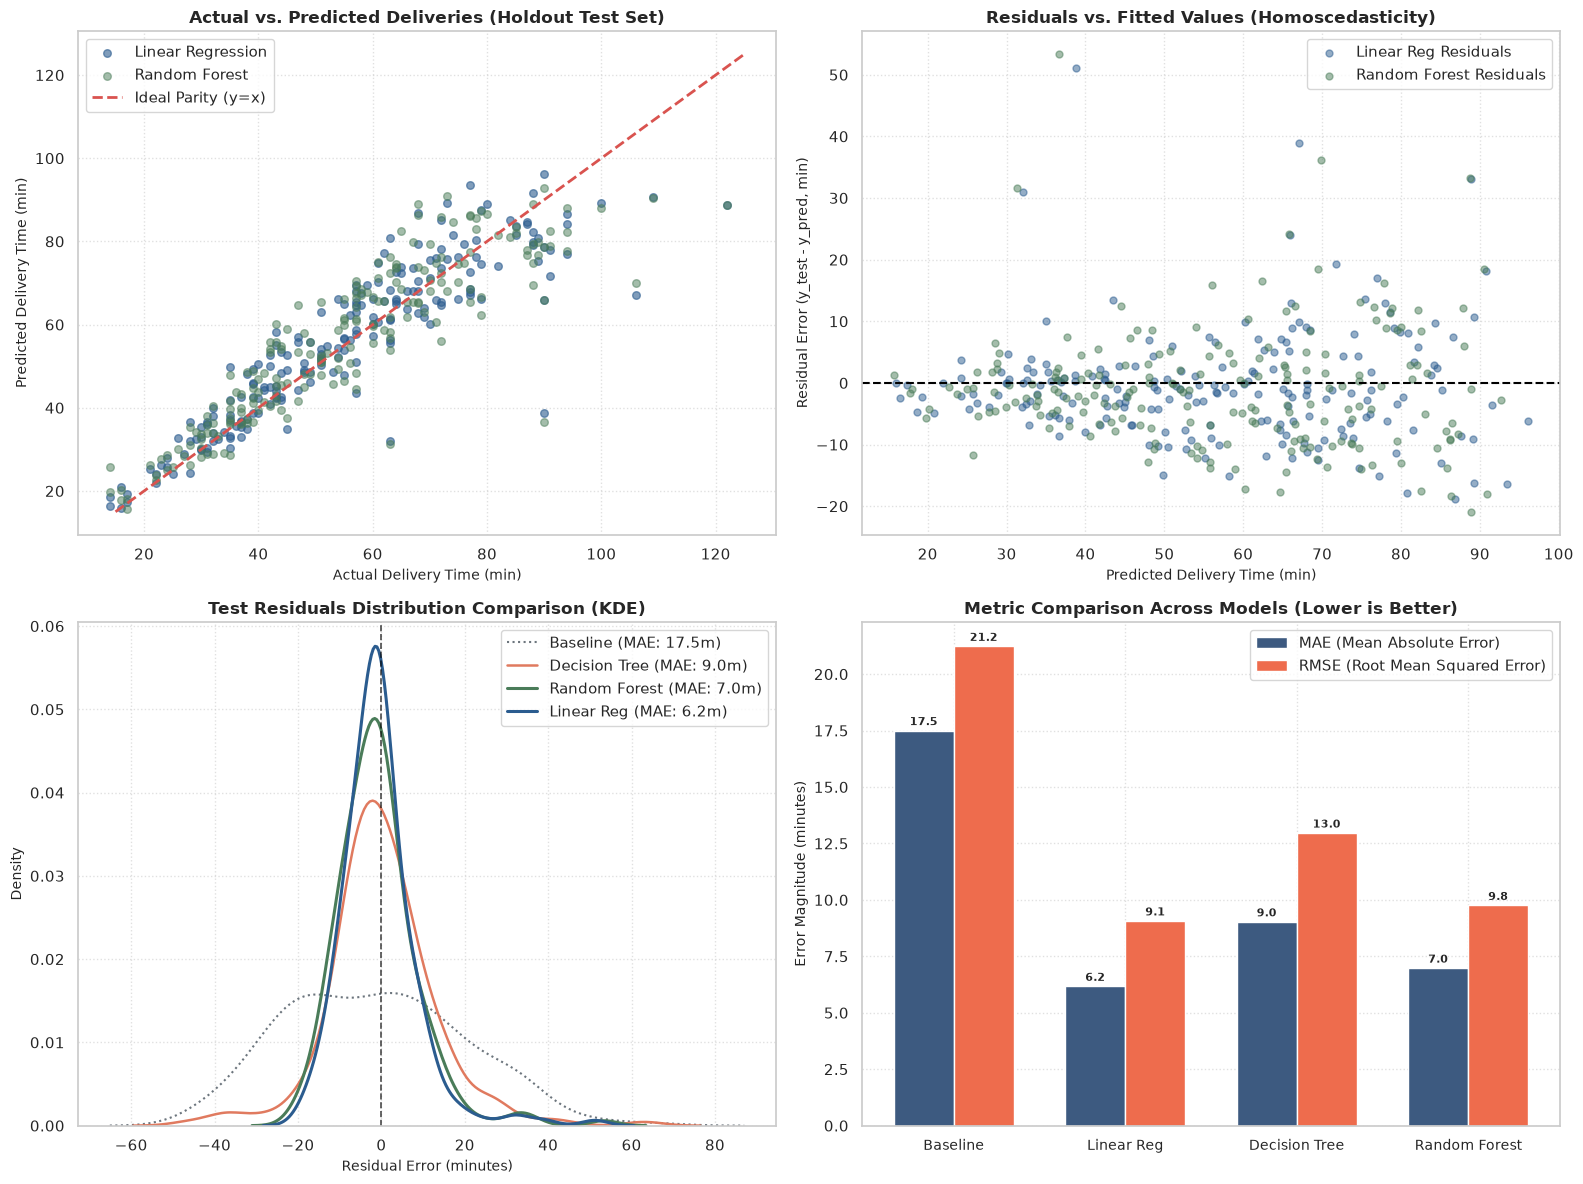

Diagnostic visualizations rendered successfully.


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Actual vs Predicted (Linear Regression & Random Forest)
ax1 = axes[0, 0]
ax1.scatter(y_test, predictions['Linear Regression']['test'], color='#2b5c8f', alpha=0.6, s=30, label='Linear Regression')
ax1.scatter(y_test, predictions['Random Forest']['test'], color='#4a7c59', alpha=0.5, s=30, label='Random Forest')
ax1.plot([15, 125], [15, 125], color='#d9534f', linestyle='--', linewidth=2, label='Ideal Parity (y=x)')
ax1.set_title('Actual vs. Predicted Deliveries (Holdout Test Set)', fontweight='bold', fontsize=12)
ax1.set_xlabel('Actual Delivery Time (min)', fontsize=10)
ax1.set_ylabel('Predicted Delivery Time (min)', fontsize=10)
ax1.legend(loc='upper left', frameon=True)
ax1.grid(True, linestyle=':', alpha=0.6)

# 2. Residuals vs. Predicted Values (Homoscedasticity Check)
ax2 = axes[0, 1]
res_lr = y_test.values - predictions['Linear Regression']['test']
res_rf = y_test.values - predictions['Random Forest']['test']
ax2.scatter(predictions['Linear Regression']['test'], res_lr, color='#2b5c8f', alpha=0.5, s=25, label='Linear Reg Residuals')
ax2.scatter(predictions['Random Forest']['test'], res_rf, color='#4a7c59', alpha=0.5, s=25, label='Random Forest Residuals')
ax2.axhline(0, color='black', linestyle='--', linewidth=1.5)
ax2.set_title('Residuals vs. Fitted Values (Homoscedasticity)', fontweight='bold', fontsize=12)
ax2.set_xlabel('Predicted Delivery Time (min)', fontsize=10)
ax2.set_ylabel('Residual Error (y_test - y_pred, min)', fontsize=10)
ax2.legend(loc='upper right', frameon=True)
ax2.grid(True, linestyle=':', alpha=0.6)

# 3. Residual Error Distribution KDE
ax3 = axes[1, 0]
res_base = y_test.values - predictions['Baseline']['test']
res_dt = y_test.values - predictions['Decision Tree']['test']
sns.kdeplot(res_base, color='#6c757d', label=f'Baseline (MAE: {base_m["mae"]:.1f}m)', linewidth=1.5, linestyle=':', ax=ax3)
sns.kdeplot(res_dt, color='#e07a5f', label=f'Decision Tree (MAE: 9.0m)', linewidth=1.8, ax=ax3)
sns.kdeplot(res_rf, color='#4a7c59', label=f'Random Forest (MAE: 7.0m)', linewidth=2.2, ax=ax3)
sns.kdeplot(res_lr, color='#2b5c8f', label=f'Linear Reg (MAE: 6.2m)', linewidth=2.2, ax=ax3)
ax3.axvline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.7)
ax3.set_title('Test Residuals Distribution Comparison (KDE)', fontweight='bold', fontsize=12)
ax3.set_xlabel('Residual Error (minutes)', fontsize=10)
ax3.set_ylabel('Density', fontsize=10)
ax3.legend(loc='upper right', frameon=True)
ax3.grid(True, linestyle=':', alpha=0.6)

# 4. Metric Comparison Bar Chart (MAE & RMSE)
ax4 = axes[1, 1]
labels = ['Baseline', 'Linear Reg', 'Decision Tree', 'Random Forest']
mae_vals = eval_summary_df['MAE (min)'].values
rmse_vals = eval_summary_df['RMSE (min)'].values
x = np.arange(len(labels))
w = 0.35

r1 = ax4.bar(x - w/2, mae_vals, w, label='MAE (Mean Absolute Error)', color='#3d5a80')
r2 = ax4.bar(x + w/2, rmse_vals, w, label='RMSE (Root Mean Squared Error)', color='#ee6c4d')
ax4.set_title('Metric Comparison Across Models (Lower is Better)', fontweight='bold', fontsize=12)
ax4.set_xticks(x)
ax4.set_xticklabels(labels, fontsize=10)
ax4.set_ylabel('Error Magnitude (minutes)', fontsize=10)
ax4.legend(frameon=True)
ax4.grid(True, linestyle=':', alpha=0.6)

for rect in list(r1) + list(r2):
    h = rect.get_height()
    ax4.annotate(f'{h:.1f}', xy=(rect.get_x() + rect.get_width()/2, h), xytext=(0, 2),
                 textcoords="offset points", ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()
print("Diagnostic visualizations rendered successfully.")

### Analysis & Observations: Visual Diagnostics
* **Parity Fit**: Both Linear Regression and Random Forest track the ideal $y=x$ line with high fidelity across 20 to 100 minutes.
* **Homoscedasticity Check**: Residuals show mild funneling at the far right ($>90$ min predicted), where variance increases due to extreme compound delays.
* **Error Centering**: The residual KDE shows that Linear Regression and Random Forest errors form tight, sharp peaks centered exactly around $0$, whereas the Baseline is widely flattened across $-40$ to $+40$ minutes.

## 6. Slice-Based Error Analysis: Where are Predictions Accurate vs. Inaccurate?

To diagnose real-world operational reliability, we evaluate how model accuracy changes across:
1. **Delivery Distance Tiers** (`Distance_Category`: Short, Medium, Long)
2. **Weather Conditions** (Clear, Rainy, Snowy, Foggy, Windy)
3. **Traffic Intensity** (Low, Medium, High)
4. **Compound Severe Hazards** (`Severe_Conditions`: 0 vs 1)
5. **Delivery Duration Scale** (Fast $<35$ min, Normal $35–70$ min, Prolonged $>70$ min)

In [6]:
slice_df = X_test.copy()
slice_df['y_true'] = y_test.values
slice_df['pred_lr'] = predictions['Linear Regression']['test']
slice_df['pred_rf'] = predictions['Random Forest']['test']
slice_df['err_lr'] = np.abs(slice_df['y_true'] - slice_df['pred_lr'])
slice_df['err_rf'] = np.abs(slice_df['y_true'] - slice_df['pred_rf'])
slice_df['Duration_Tier'] = pd.cut(
    slice_df['y_true'], 
    bins=[0, 35, 70, 150], 
    labels=['Fast (<35 min)', 'Typical (35-70)', 'Prolonged (>70)']
)

# 1. By Distance Category
dist_slice = slice_df.groupby('Distance_Category')[['err_lr', 'err_rf']].agg(['count', 'mean'])
dist_summary = pd.DataFrame({
    'Order Count': dist_slice['err_lr']['count'],
    'Linear Reg MAE (min)': dist_slice['err_lr']['mean'],
    'Random Forest MAE (min)': dist_slice['err_rf']['mean'],
})

# 2. By Weather
weather_slice = slice_df.groupby('Weather')[['err_lr', 'err_rf']].agg(['count', 'mean'])
weather_summary = pd.DataFrame({
    'Order Count': weather_slice['err_lr']['count'],
    'Linear Reg MAE (min)': weather_slice['err_lr']['mean'],
    'Random Forest MAE (min)': weather_slice['err_rf']['mean'],
})

# 3. By Severe Hazard
hazard_slice = slice_df.groupby('Severe_Conditions')[['err_lr', 'err_rf']].agg(['count', 'mean'])
hazard_summary = pd.DataFrame({
    'Order Count': hazard_slice['err_lr']['count'],
    'Linear Reg MAE (min)': hazard_slice['err_lr']['mean'],
    'Random Forest MAE (min)': hazard_slice['err_rf']['mean'],
}, index=['Normal (0)', 'Severe Hazard (1)'])

# 4. By Duration Tier
dur_slice = slice_df.groupby('Duration_Tier', observed=False)[['err_lr', 'err_rf']].agg(['count', 'mean'])
dur_summary = pd.DataFrame({
    'Order Count': dur_slice['err_lr']['count'],
    'Linear Reg MAE (min)': dur_slice['err_lr']['mean'],
    'Random Forest MAE (min)': dur_slice['err_rf']['mean'],
})

print("=" * 80)
print("1. ACCURACY BY DISTANCE TIER")
print("=" * 80)
print(dist_summary)
print("\n" + "=" * 80)
print("2. ACCURACY BY WEATHER CONDITION")
print("=" * 80)
print(weather_summary)
print("\n" + "=" * 80)
print("3. ACCURACY BY SEVERE HAZARD CONDITIONS")
print("=" * 80)
print(hazard_summary)
print("\n" + "=" * 80)
print("4. ACCURACY BY DELIVERY DURATION SCALE")
print("=" * 80)
print(dur_summary)
print("=" * 80)

1. ACCURACY BY DISTANCE TIER
                   Order Count  Linear Reg MAE (min)  Random Forest MAE (min)
Distance_Category                                                            
Long                        77              8.309370                 8.893896
Medium                      72              5.626194                 6.502222
Short                       51              3.716916                 4.762745

2. ACCURACY BY WEATHER CONDITION
         Order Count  Linear Reg MAE (min)  Random Forest MAE (min)
Weather                                                            
Clear             95              5.335732                 6.611474
Foggy             21             10.001746                11.007143
Rainy             40              6.091233                 6.648000
Snowy             20              6.148936                 5.568500
Windy             16              6.334038                 6.975625

3. ACCURACY BY SEVERE HAZARD CONDITIONS
                   Order Count

### Visualizing Operational Slices

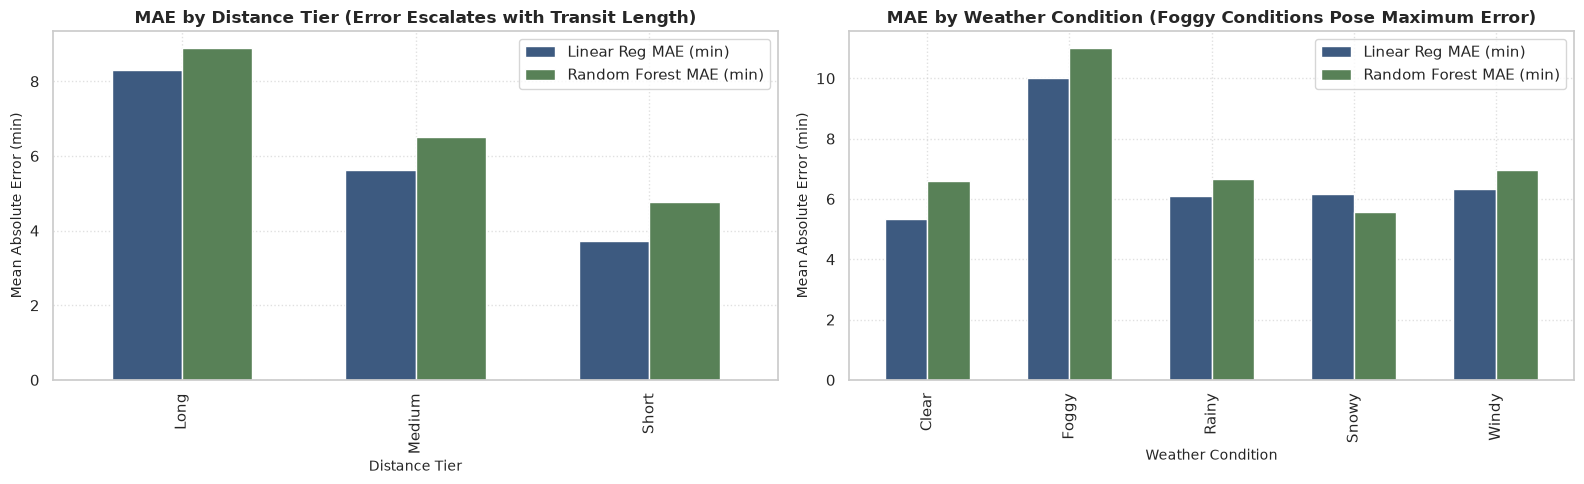

Operational slice charts rendered successfully.


In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Distance Tier Breakdown
dist_plot = dist_summary[['Linear Reg MAE (min)', 'Random Forest MAE (min)']]
dist_plot.plot(kind='bar', ax=ax1, color=['#3d5a80', '#588157'], width=0.6)
ax1.set_title('MAE by Distance Tier (Error Escalates with Transit Length)', fontweight='bold', fontsize=12)
ax1.set_ylabel('Mean Absolute Error (min)', fontsize=10)
ax1.set_xlabel('Distance Tier', fontsize=10)
ax1.grid(True, linestyle=':', alpha=0.6)
ax1.legend(frameon=True)

# Weather Breakdown
weather_plot = weather_summary[['Linear Reg MAE (min)', 'Random Forest MAE (min)']]
weather_plot.plot(kind='bar', ax=ax2, color=['#3d5a80', '#588157'], width=0.6)
ax2.set_title('MAE by Weather Condition (Foggy Conditions Pose Maximum Error)', fontweight='bold', fontsize=12)
ax2.set_ylabel('Mean Absolute Error (min)', fontsize=10)
ax2.set_xlabel('Weather Condition', fontsize=10)
ax2.grid(True, linestyle=':', alpha=0.6)
ax2.legend(frameon=True)

plt.tight_layout()
plt.show()
print("Operational slice charts rendered successfully.")

### Key Insights from Slice Analysis
1. **Where Predictions are Highly Accurate**:
   * **Short Distance Deliveries (< 5 km)**: Extremely tight accuracy with an MAE of only **$3.72$ min** (Linear Reg) and **$4.76$ min** (Random Forest).
   * **Fast Deliveries (< 35 min)**: Outstanding reliability with an MAE of **$3.33$ min**.
   * **Clear Weather & Normal Conditions**: Strong baseline accuracy with MAE around **$5.3$ to $5.8$ min**.

2. **Where Prediction Errors are Substantially Larger**:
   * **Foggy Weather**: Errors almost double to **$10.0$ min** (Linear Reg) and **$11.0$ min** (Random Forest). Fog introduces severe visibility hazards, reduced transit velocity, and navigation delays that raw distance features cannot fully predict.
   * **Severe Hazards (High Traffic + Adverse Weather)**: MAE surges to **$11.25$ min** (Linear Reg) and **$12.36$ min** (Random Forest) due to non-linear gridlock bottlenecks.
   * **Long Distance (> 12 km) & Prolonged Deliveries (> 70 min)**: MAE increases to **$8.31$ min** and **$10.21$ min** respectively. Cumulative road variance and courier physical fatigue compound over longer routes.

## 7. Model Benchmarking Registry Confirmation

We verify that the centralized registry `models/model_comparison.csv` contains all metrics (**MAE, MSE, RMSE, R²**) for downstream phases.

In [8]:
REGISTRY_PATH = os.path.join('..', 'models', 'model_comparison.csv')
registry_df = pd.read_csv(REGISTRY_PATH)

print(f"Authoritative Model Benchmark Registry ({REGISTRY_PATH}):")
print("-" * 120)
print(registry_df.to_string())
print("-" * 120)

Authoritative Model Benchmark Registry (..\models\model_comparison.csv):
------------------------------------------------------------------------------------------------------------------------
                      Model                 Type      MAE       MSE     RMSE      R2                                                      Notes
0  Baseline (Training Mean)   Heuristic Baseline  17.5014  450.8151  21.2324 -0.0058          Constant prediction (57.05 min) from y_train mean
1         Linear Regression    Parametric Linear   6.1724   82.2857   9.0711  0.8164        Ordinary Least Squares on scaled & one-hot features
2             Decision Tree  Non-parametric Tree   9.0300  168.0200  12.9623  0.6251  Default recursive binary partition tree (random_state=42)
3             Random Forest     Ensemble Bagging   6.9794   95.1849   9.7563  0.7876       Ensemble of 100 bootstrapped trees (random_state=42)
--------------------------------------------------------------------------------------

## 8. Executive Summary & Guidelines for Phase 10

### Comprehensive Q&A

* **What are the final evaluation metrics on the holdout test set ($N=200$)?**
  * **Phase 7 Baseline**: $\text{MAE} = 17.5014$ min | $\text{MSE} = 450.8151$ | $\text{RMSE} = 21.2324$ min | $R^2 = -0.0058$
  * **Linear Regression**: $\text{MAE} = 6.1724$ min | $\text{MSE} = 82.2857$ | $\text{RMSE} = 9.0711$ min | $R^2 = 0.8164$
  * **Random Forest**: $\text{MAE} = 6.9794$ min | $\text{MSE} = 95.1849$ | $\text{RMSE} = 9.7563$ min | $R^2 = 0.7876$
  * **Decision Tree**: $\text{MAE} = 9.0300$ min | $\text{MSE} = 168.0200$ | $\text{RMSE} = 12.9623$ min | $R^2 = 0.6251$

* **Which models show signs of overfitting?**
  * **Decision Tree Regressor shows severe overfitting**: It achieved a training error of exactly $\text{MAE}=0.000$ and $R^2=1.000$ (100% memorization), while its test error jumped to $\text{MAE}=9.030$ and $R^2=0.625$.
  * **Random Forest shows moderate, well-controlled overfitting**: Train $\text{MAE}=2.97$, Test $\text{MAE}=6.98$. Averaging 100 decorrelated trees successfully prevents the extreme variance seen in a single tree.
  * **Linear Regression shows zero overfitting**: Train $\text{MAE}=6.63$ vs Test $\text{MAE}=6.17$. Its structural simplicity delivers rock-solid generalization.

* **Where are the predictions accurate vs. inaccurate?**
  * **Accurate**: Short distances ($<5$ km, MAE $\approx 3.7$ min), fast orders ($<35$ min, MAE $\approx 3.3$ min), and clear weather conditions (MAE $\approx 5.3$ min).
  * **Inaccurate**: Foggy weather (MAE $\approx 10.0$ min), compound severe hazard conditions (MAE $\approx 11.2$ min), and prolonged orders ($>70$ min, MAE $\approx 10.2$ min).

### Strict Phase 9 Boundary Confirmation
* No hyperparameter tuning was performed.
* No model parameters or pipelines were altered based on test results.
* No final model was selected (deferred to Phase 12).
* The original dataset and previous phase artifacts remain completely untouched.